In [1]:
import os
import nibabel as nib
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from monai.transforms import KeepLargestConnectedComponent
import glob

In [2]:
ROOT_DIR = "/home/fehrdelt/bettik/"
#ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

In [3]:
soop_maks_acute_folder = ROOT_DIR+"/datasets/final_soop_dataset_small/masks_acute_registered/"
mask_files = sorted([f for f in os.listdir(soop_maks_acute_folder) if f.endswith('.nii') or f.endswith('.nii.gz')])

In [4]:
large_group_threshold = 15000 # minimum size of the largest connected component to be considered in large group
medium_group_threshold = 5000 # minimum size of the largest connected component to be considered in medium group
small_group_threshold = 0 # minimum size of the largest connected component to be considered in small group

large_group = []
medium_group = []
small_group = []

In [5]:
# distribute masks into groups based on the size of the largest connected component visible in the middle axial slice


# Initialize the transform
keep_largest = KeepLargestConnectedComponent()

# Count pixels in largest connected component for each mask
largest_component_sizes = []

for mask_file in tqdm(mask_files):
    # Load mask image
    mask_img = nib.load(os.path.join(soop_maks_acute_folder, mask_file))
    mask_data = mask_img.get_fdata()

    
    # Convert to binary mask
    binary_mask = mask_data > 0
    
    if np.any(binary_mask):
        # Apply MONAI's KeepLargestConnectedComponent
        largest_component = keep_largest(binary_mask.astype(np.float32))
        largest_component_size = int(np.sum(largest_component))
    else:
        largest_component_size = 0

    if largest_component_size >= large_group_threshold:
        large_group.append(mask_file)
    elif largest_component_size >= medium_group_threshold:
        medium_group.append(mask_file)
    elif largest_component_size >= small_group_threshold:
        small_group.append(mask_file)
    
    largest_component_sizes.append(largest_component_size)
    #print(f"{mask_file}: {largest_component_size} pixels in largest component")

print(f"\nSummary:")
print(f"Mean largest component size: {np.mean(largest_component_sizes):.2f}, n={len(largest_component_sizes)}")
print('\n')
print(f"Large group (>{large_group_threshold} pixels): {len(large_group)} masks")
print(f"Medium group (>{medium_group_threshold} pixels): {len(medium_group)} masks")
print(f"Small group (>{small_group_threshold} pixels): {len(small_group)} masks")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1451/1451 [03:15<00:00,  7.42it/s]


Summary:
Mean largest component size: 7415.44, n=1451


Large group (>15000 pixels): 212 masks
Medium group (>5000 pixels): 295 masks
Small group (>0 pixels): 944 masks


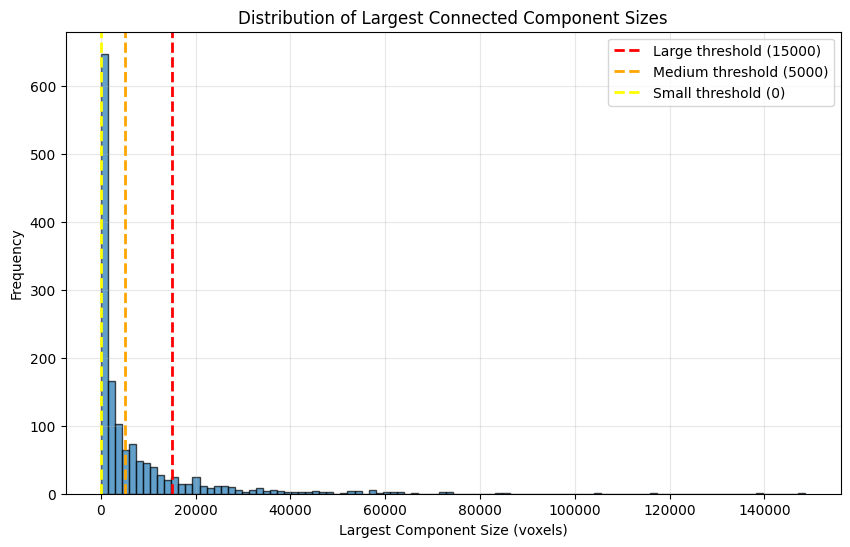

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(largest_component_sizes, bins=100, edgecolor='black', alpha=0.7)
plt.axvline(large_group_threshold, color='red', linestyle='--', linewidth=2, label=f'Large threshold ({large_group_threshold})')
plt.axvline(medium_group_threshold, color='orange', linestyle='--', linewidth=2, label=f'Medium threshold ({medium_group_threshold})')
plt.axvline(small_group_threshold, color='yellow', linestyle='--', linewidth=2, label=f'Small threshold ({small_group_threshold})')
plt.xlabel('Largest Component Size (voxels)')
plt.ylabel('Frequency')
plt.title('Distribution of Largest Connected Component Sizes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

overflow encountered in power
linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r-" (-> linestyle='-'). The keyword argument will take precedence.


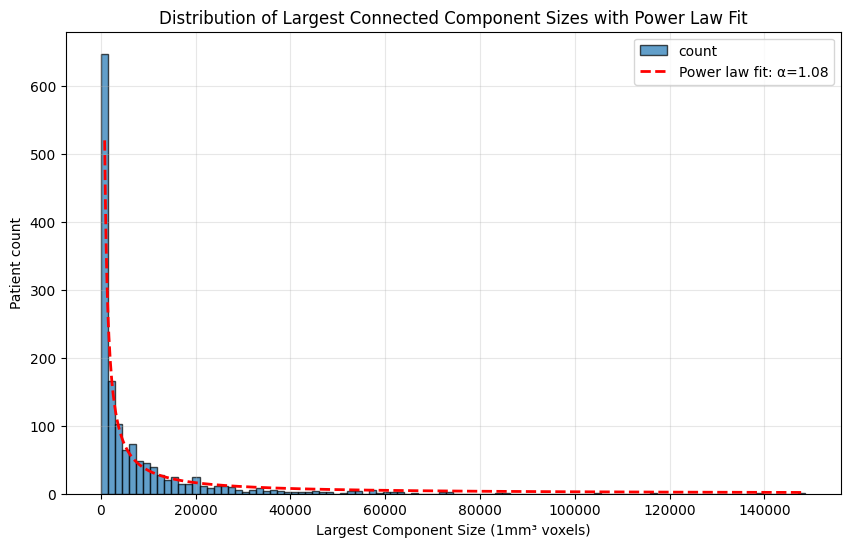

Power law parameters: a=699499.17, alpha=1.08


In [7]:
from scipy import stats
from scipy.optimize import curve_fit

# Remove zeros and small values for power law fitting
min_size_for_fit = 800

sizes_filtered = [s for s in largest_component_sizes if s >= min_size_for_fit]

# Fit power law: y = a * x^(-alpha)
def power_law(x, a, alpha):
    return a * (x ** (-alpha))

# Create histogram data
hist, bin_edges = np.histogram(sizes_filtered, bins=100)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Filter out zero counts for fitting
mask = hist > 0
bin_centers_fit = bin_centers[mask]
hist_fit = hist[mask]

# Fit the power law
try:
    params, _ = curve_fit(power_law, bin_centers_fit, hist_fit, p0=[max(hist_fit), 1.5])
    a_fit, alpha_fit = params
    
    # Generate fitted curve
    x_fit = np.linspace(min_size_for_fit, max(sizes_filtered), 1000)
    y_fit = power_law(x_fit, a_fit, alpha_fit)
    
    plt.figure(figsize=(10, 6))
    plt.hist(largest_component_sizes, bins=100, edgecolor='black', alpha=0.7, label='count')

    plt.plot(x_fit, y_fit, 'r-', linewidth=2, label=f'Power law fit: α={alpha_fit:.2f}', linestyle='--')
    plt.xlabel('Largest Component Size (1mm³ voxels)')
    plt.ylabel('Patient count')
    plt.title('Distribution of Largest Connected Component Sizes with Power Law Fit')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"Power law parameters: a={a_fit:.2f}, alpha={alpha_fit:.2f}")
except:
    print("Power law fitting failed")

In [8]:
print(large_group)
print(medium_group)
print(small_group)

['sub-1010.nii.gz', 'sub-1013.nii.gz', 'sub-1015.nii.gz', 'sub-1032.nii.gz', 'sub-1035.nii.gz', 'sub-1039.nii.gz', 'sub-1041.nii.gz', 'sub-1045.nii.gz', 'sub-1046.nii.gz', 'sub-1071.nii.gz', 'sub-1073.nii.gz', 'sub-1086.nii.gz', 'sub-1102.nii.gz', 'sub-1107.nii.gz', 'sub-1115.nii.gz', 'sub-113.nii.gz', 'sub-114.nii.gz', 'sub-1149.nii.gz', 'sub-1150.nii.gz', 'sub-116.nii.gz', 'sub-1164.nii.gz', 'sub-1165.nii.gz', 'sub-118.nii.gz', 'sub-1200.nii.gz', 'sub-1204.nii.gz', 'sub-1209.nii.gz', 'sub-1213.nii.gz', 'sub-1215.nii.gz', 'sub-1223.nii.gz', 'sub-1227.nii.gz', 'sub-1232.nii.gz', 'sub-1246.nii.gz', 'sub-1258.nii.gz', 'sub-127.nii.gz', 'sub-1280.nii.gz', 'sub-1282.nii.gz', 'sub-1283.nii.gz', 'sub-1285.nii.gz', 'sub-1292.nii.gz', 'sub-1305.nii.gz', 'sub-1306.nii.gz', 'sub-1309.nii.gz', 'sub-1312.nii.gz', 'sub-1314.nii.gz', 'sub-1320.nii.gz', 'sub-1323.nii.gz', 'sub-135.nii.gz', 'sub-1354.nii.gz', 'sub-1355.nii.gz', 'sub-1358.nii.gz', 'sub-1364.nii.gz', 'sub-1366.nii.gz', 'sub-1369.nii.gz'

In [9]:
print([name.split('_')[0] for name in large_group])
print([name.split('_')[0] for name in medium_group])
print([name.split('_')[0] for name in small_group])

['sub-1010.nii.gz', 'sub-1013.nii.gz', 'sub-1015.nii.gz', 'sub-1032.nii.gz', 'sub-1035.nii.gz', 'sub-1039.nii.gz', 'sub-1041.nii.gz', 'sub-1045.nii.gz', 'sub-1046.nii.gz', 'sub-1071.nii.gz', 'sub-1073.nii.gz', 'sub-1086.nii.gz', 'sub-1102.nii.gz', 'sub-1107.nii.gz', 'sub-1115.nii.gz', 'sub-113.nii.gz', 'sub-114.nii.gz', 'sub-1149.nii.gz', 'sub-1150.nii.gz', 'sub-116.nii.gz', 'sub-1164.nii.gz', 'sub-1165.nii.gz', 'sub-118.nii.gz', 'sub-1200.nii.gz', 'sub-1204.nii.gz', 'sub-1209.nii.gz', 'sub-1213.nii.gz', 'sub-1215.nii.gz', 'sub-1223.nii.gz', 'sub-1227.nii.gz', 'sub-1232.nii.gz', 'sub-1246.nii.gz', 'sub-1258.nii.gz', 'sub-127.nii.gz', 'sub-1280.nii.gz', 'sub-1282.nii.gz', 'sub-1283.nii.gz', 'sub-1285.nii.gz', 'sub-1292.nii.gz', 'sub-1305.nii.gz', 'sub-1306.nii.gz', 'sub-1309.nii.gz', 'sub-1312.nii.gz', 'sub-1314.nii.gz', 'sub-1320.nii.gz', 'sub-1323.nii.gz', 'sub-135.nii.gz', 'sub-1354.nii.gz', 'sub-1355.nii.gz', 'sub-1358.nii.gz', 'sub-1364.nii.gz', 'sub-1366.nii.gz', 'sub-1369.nii.gz'

In [21]:
print([name.replace('.nii.gz', '') for name in large_group])
print([name.replace('.nii.gz', '') for name in medium_group])
print([name.replace('.nii.gz', '') for name in small_group])

['sub-1010', 'sub-1013', 'sub-1015', 'sub-1032', 'sub-1035', 'sub-1039', 'sub-1041', 'sub-1045', 'sub-1046', 'sub-1071', 'sub-1073', 'sub-1086', 'sub-1102', 'sub-1107', 'sub-1115', 'sub-113', 'sub-114', 'sub-1149', 'sub-1150', 'sub-116', 'sub-1164', 'sub-1165', 'sub-118', 'sub-1200', 'sub-1204', 'sub-1209', 'sub-1213', 'sub-1215', 'sub-1223', 'sub-1227', 'sub-1232', 'sub-1246', 'sub-1258', 'sub-127', 'sub-1280', 'sub-1282', 'sub-1283', 'sub-1285', 'sub-1292', 'sub-1305', 'sub-1306', 'sub-1309', 'sub-1312', 'sub-1314', 'sub-1320', 'sub-1323', 'sub-135', 'sub-1354', 'sub-1355', 'sub-1358', 'sub-1364', 'sub-1366', 'sub-1369', 'sub-1373', 'sub-1379', 'sub-1382', 'sub-1386', 'sub-1395', 'sub-1409', 'sub-1410', 'sub-1413', 'sub-1422', 'sub-1432', 'sub-1445', 'sub-1447', 'sub-1475', 'sub-1478', 'sub-1480', 'sub-1483', 'sub-1485', 'sub-1488', 'sub-1507', 'sub-1508', 'sub-1511', 'sub-1517', 'sub-1552', 'sub-1554', 'sub-1555', 'sub-1569', 'sub-1598', 'sub-1612', 'sub-1634', 'sub-1637', 'sub-1656

In [11]:

large_group = ['sub-1010.nii.gz', 'sub-1013.nii.gz', 'sub-1015.nii.gz', 'sub-1032.nii.gz', 'sub-1035.nii.gz', 'sub-1039.nii.gz', 'sub-1041.nii.gz', 'sub-1045.nii.gz', 'sub-1046.nii.gz', 'sub-1071.nii.gz', 'sub-1073.nii.gz', 'sub-1086.nii.gz', 'sub-1102.nii.gz', 'sub-1107.nii.gz', 'sub-1115.nii.gz', 'sub-113.nii.gz', 'sub-114.nii.gz', 'sub-1149.nii.gz', 'sub-1150.nii.gz', 'sub-116.nii.gz', 'sub-1164.nii.gz', 'sub-1165.nii.gz', 'sub-118.nii.gz', 'sub-1200.nii.gz', 'sub-1204.nii.gz', 'sub-1209.nii.gz', 'sub-1213.nii.gz', 'sub-1215.nii.gz', 'sub-1223.nii.gz', 'sub-1227.nii.gz', 'sub-1232.nii.gz', 'sub-1246.nii.gz', 'sub-1258.nii.gz', 'sub-127.nii.gz', 'sub-1280.nii.gz', 'sub-1282.nii.gz', 'sub-1283.nii.gz', 'sub-1285.nii.gz', 'sub-1292.nii.gz', 'sub-1305.nii.gz', 'sub-1306.nii.gz', 'sub-1309.nii.gz', 'sub-1312.nii.gz', 'sub-1314.nii.gz', 'sub-1320.nii.gz', 'sub-1323.nii.gz', 'sub-135.nii.gz', 'sub-1354.nii.gz', 'sub-1355.nii.gz', 'sub-1358.nii.gz', 'sub-1364.nii.gz', 'sub-1366.nii.gz', 'sub-1369.nii.gz', 'sub-1373.nii.gz', 'sub-1379.nii.gz', 'sub-1382.nii.gz', 'sub-1386.nii.gz', 'sub-1395.nii.gz', 'sub-1409.nii.gz', 'sub-1410.nii.gz', 'sub-1413.nii.gz', 'sub-1422.nii.gz', 'sub-1432.nii.gz', 'sub-1445.nii.gz', 'sub-1447.nii.gz', 'sub-1475.nii.gz', 'sub-1478.nii.gz', 'sub-1480.nii.gz', 'sub-1483.nii.gz', 'sub-1485.nii.gz', 'sub-1488.nii.gz', 'sub-1507.nii.gz', 'sub-1508.nii.gz', 'sub-1511.nii.gz', 'sub-1517.nii.gz', 'sub-1552.nii.gz', 'sub-1554.nii.gz', 'sub-1555.nii.gz', 'sub-1569.nii.gz', 'sub-1598.nii.gz', 'sub-1612.nii.gz', 'sub-1634.nii.gz', 'sub-1637.nii.gz', 'sub-1656.nii.gz', 'sub-1670.nii.gz', 'sub-1677.nii.gz', 'sub-1719.nii.gz', 'sub-1725.nii.gz', 'sub-1727.nii.gz', 'sub-1736.nii.gz', 'sub-174.nii.gz', 'sub-177.nii.gz', 'sub-185.nii.gz', 'sub-190.nii.gz', 'sub-196.nii.gz', 'sub-198.nii.gz', 'sub-2.nii.gz', 'sub-221.nii.gz', 'sub-235.nii.gz', 'sub-241.nii.gz', 'sub-247.nii.gz', 'sub-249.nii.gz', 'sub-260.nii.gz', 'sub-262.nii.gz', 'sub-264.nii.gz', 'sub-278.nii.gz', 'sub-284.nii.gz', 'sub-294.nii.gz', 'sub-3.nii.gz', 'sub-303.nii.gz', 'sub-314.nii.gz', 'sub-321.nii.gz', 'sub-326.nii.gz', 'sub-335.nii.gz', 'sub-338.nii.gz', 'sub-339.nii.gz', 'sub-341.nii.gz', 'sub-343.nii.gz', 'sub-345.nii.gz', 'sub-359.nii.gz', 'sub-360.nii.gz', 'sub-366.nii.gz', 'sub-370.nii.gz', 'sub-374.nii.gz', 'sub-386.nii.gz', 'sub-398.nii.gz', 'sub-400.nii.gz', 'sub-401.nii.gz', 'sub-412.nii.gz', 'sub-42.nii.gz', 'sub-422.nii.gz', 'sub-432.nii.gz', 'sub-433.nii.gz', 'sub-443.nii.gz', 'sub-446.nii.gz', 'sub-447.nii.gz', 'sub-457.nii.gz', 'sub-463.nii.gz', 'sub-464.nii.gz', 'sub-466.nii.gz', 'sub-47.nii.gz', 'sub-494.nii.gz', 'sub-498.nii.gz', 'sub-501.nii.gz', 'sub-505.nii.gz', 'sub-512.nii.gz', 'sub-517.nii.gz', 'sub-521.nii.gz', 'sub-523.nii.gz', 'sub-525.nii.gz', 'sub-529.nii.gz', 'sub-53.nii.gz', 'sub-530.nii.gz', 'sub-539.nii.gz', 'sub-543.nii.gz', 'sub-56.nii.gz', 'sub-563.nii.gz', 'sub-572.nii.gz', 'sub-613.nii.gz', 'sub-620.nii.gz', 'sub-631.nii.gz', 'sub-634.nii.gz', 'sub-638.nii.gz', 'sub-651.nii.gz', 'sub-652.nii.gz', 'sub-661.nii.gz', 'sub-682.nii.gz', 'sub-692.nii.gz', 'sub-694.nii.gz', 'sub-698.nii.gz', 'sub-699.nii.gz', 'sub-707.nii.gz', 'sub-719.nii.gz', 'sub-723.nii.gz', 'sub-724.nii.gz', 'sub-751.nii.gz', 'sub-754.nii.gz', 'sub-760.nii.gz', 'sub-761.nii.gz', 'sub-768.nii.gz', 'sub-776.nii.gz', 'sub-789.nii.gz', 'sub-79.nii.gz', 'sub-791.nii.gz', 'sub-8.nii.gz', 'sub-803.nii.gz', 'sub-806.nii.gz', 'sub-82.nii.gz', 'sub-823.nii.gz', 'sub-826.nii.gz', 'sub-843.nii.gz', 'sub-844.nii.gz', 'sub-845.nii.gz', 'sub-858.nii.gz', 'sub-861.nii.gz', 'sub-865.nii.gz', 'sub-866.nii.gz', 'sub-873.nii.gz', 'sub-877.nii.gz', 'sub-881.nii.gz', 'sub-896.nii.gz', 'sub-917.nii.gz', 'sub-937.nii.gz', 'sub-939.nii.gz', 'sub-942.nii.gz', 'sub-946.nii.gz', 'sub-95.nii.gz', 'sub-952.nii.gz', 'sub-959.nii.gz', 'sub-960.nii.gz', 'sub-968.nii.gz', 'sub-990.nii.gz']
medium_group = ['sub-100.nii.gz', 'sub-1011.nii.gz', 'sub-1014.nii.gz', 'sub-1016.nii.gz', 'sub-1018.nii.gz', 'sub-102.nii.gz', 'sub-1024.nii.gz', 'sub-103.nii.gz', 'sub-1052.nii.gz', 'sub-1054.nii.gz', 'sub-1055.nii.gz', 'sub-1056.nii.gz', 'sub-1057.nii.gz', 'sub-106.nii.gz', 'sub-1064.nii.gz', 'sub-1075.nii.gz', 'sub-1076.nii.gz', 'sub-1096.nii.gz', 'sub-110.nii.gz', 'sub-1101.nii.gz', 'sub-1105.nii.gz', 'sub-1106.nii.gz', 'sub-1113.nii.gz', 'sub-1118.nii.gz', 'sub-1119.nii.gz', 'sub-112.nii.gz', 'sub-1120.nii.gz', 'sub-1127.nii.gz', 'sub-1128.nii.gz', 'sub-1130.nii.gz', 'sub-1136.nii.gz', 'sub-1140.nii.gz', 'sub-1144.nii.gz', 'sub-1147.nii.gz', 'sub-1148.nii.gz', 'sub-1154.nii.gz', 'sub-1157.nii.gz', 'sub-1163.nii.gz', 'sub-1182.nii.gz', 'sub-1183.nii.gz', 'sub-1186.nii.gz', 'sub-1189.nii.gz', 'sub-1193.nii.gz', 'sub-1198.nii.gz', 'sub-1202.nii.gz', 'sub-1211.nii.gz', 'sub-1212.nii.gz', 'sub-1217.nii.gz', 'sub-122.nii.gz', 'sub-1229.nii.gz', 'sub-123.nii.gz', 'sub-1234.nii.gz', 'sub-1237.nii.gz', 'sub-1239.nii.gz', 'sub-124.nii.gz', 'sub-1242.nii.gz', 'sub-1244.nii.gz', 'sub-1248.nii.gz', 'sub-1260.nii.gz', 'sub-1266.nii.gz', 'sub-128.nii.gz', 'sub-1281.nii.gz', 'sub-129.nii.gz', 'sub-1291.nii.gz', 'sub-1296.nii.gz', 'sub-1297.nii.gz', 'sub-1301.nii.gz', 'sub-131.nii.gz', 'sub-1310.nii.gz', 'sub-1319.nii.gz', 'sub-1324.nii.gz', 'sub-1326.nii.gz', 'sub-1330.nii.gz', 'sub-1331.nii.gz', 'sub-1332.nii.gz', 'sub-1338.nii.gz', 'sub-1346.nii.gz', 'sub-1347.nii.gz', 'sub-1348.nii.gz', 'sub-1349.nii.gz', 'sub-1352.nii.gz', 'sub-1363.nii.gz', 'sub-1370.nii.gz', 'sub-1374.nii.gz', 'sub-138.nii.gz', 'sub-1380.nii.gz', 'sub-1388.nii.gz', 'sub-1396.nii.gz', 'sub-1404.nii.gz', 'sub-1408.nii.gz', 'sub-1415.nii.gz', 'sub-1417.nii.gz', 'sub-1423.nii.gz', 'sub-1427.nii.gz', 'sub-1429.nii.gz', 'sub-1438.nii.gz', 'sub-1440.nii.gz', 'sub-1443.nii.gz', 'sub-1446.nii.gz', 'sub-1449.nii.gz', 'sub-145.nii.gz', 'sub-1450.nii.gz', 'sub-146.nii.gz', 'sub-1463.nii.gz', 'sub-1466.nii.gz', 'sub-147.nii.gz', 'sub-148.nii.gz', 'sub-1489.nii.gz', 'sub-1490.nii.gz', 'sub-1494.nii.gz', 'sub-1496.nii.gz', 'sub-1501.nii.gz', 'sub-1503.nii.gz', 'sub-1506.nii.gz', 'sub-1509.nii.gz', 'sub-1514.nii.gz', 'sub-1518.nii.gz', 'sub-1519.nii.gz', 'sub-1521.nii.gz', 'sub-1522.nii.gz', 'sub-1523.nii.gz', 'sub-1525.nii.gz', 'sub-1541.nii.gz', 'sub-1545.nii.gz', 'sub-1548.nii.gz', 'sub-155.nii.gz', 'sub-1550.nii.gz', 'sub-1556.nii.gz', 'sub-1557.nii.gz', 'sub-156.nii.gz', 'sub-1562.nii.gz', 'sub-1567.nii.gz', 'sub-1568.nii.gz', 'sub-1571.nii.gz', 'sub-1578.nii.gz', 'sub-1583.nii.gz', 'sub-1595.nii.gz', 'sub-16.nii.gz', 'sub-1603.nii.gz', 'sub-1605.nii.gz', 'sub-1608.nii.gz', 'sub-161.nii.gz', 'sub-1629.nii.gz', 'sub-1638.nii.gz', 'sub-1646.nii.gz', 'sub-165.nii.gz', 'sub-1652.nii.gz', 'sub-1660.nii.gz', 'sub-1672.nii.gz', 'sub-1673.nii.gz', 'sub-1674.nii.gz', 'sub-1678.nii.gz', 'sub-1682.nii.gz', 'sub-1683.nii.gz', 'sub-1688.nii.gz', 'sub-1695.nii.gz', 'sub-1697.nii.gz', 'sub-1701.nii.gz', 'sub-1707.nii.gz', 'sub-1715.nii.gz', 'sub-191.nii.gz', 'sub-203.nii.gz', 'sub-204.nii.gz', 'sub-206.nii.gz', 'sub-219.nii.gz', 'sub-243.nii.gz', 'sub-245.nii.gz', 'sub-25.nii.gz', 'sub-27.nii.gz', 'sub-273.nii.gz', 'sub-274.nii.gz', 'sub-277.nii.gz', 'sub-289.nii.gz', 'sub-295.nii.gz', 'sub-296.nii.gz', 'sub-297.nii.gz', 'sub-305.nii.gz', 'sub-320.nii.gz', 'sub-322.nii.gz', 'sub-328.nii.gz', 'sub-329.nii.gz', 'sub-33.nii.gz', 'sub-330.nii.gz', 'sub-331.nii.gz', 'sub-332.nii.gz', 'sub-333.nii.gz', 'sub-344.nii.gz', 'sub-348.nii.gz', 'sub-35.nii.gz', 'sub-352.nii.gz', 'sub-355.nii.gz', 'sub-36.nii.gz', 'sub-364.nii.gz', 'sub-379.nii.gz', 'sub-382.nii.gz', 'sub-384.nii.gz', 'sub-397.nii.gz', 'sub-403.nii.gz', 'sub-408.nii.gz', 'sub-409.nii.gz', 'sub-415.nii.gz', 'sub-416.nii.gz', 'sub-420.nii.gz', 'sub-426.nii.gz', 'sub-435.nii.gz', 'sub-444.nii.gz', 'sub-449.nii.gz', 'sub-462.nii.gz', 'sub-467.nii.gz', 'sub-473.nii.gz', 'sub-478.nii.gz', 'sub-485.nii.gz', 'sub-487.nii.gz', 'sub-49.nii.gz', 'sub-490.nii.gz', 'sub-50.nii.gz', 'sub-507.nii.gz', 'sub-515.nii.gz', 'sub-518.nii.gz', 'sub-522.nii.gz', 'sub-538.nii.gz', 'sub-541.nii.gz', 'sub-542.nii.gz', 'sub-544.nii.gz', 'sub-546.nii.gz', 'sub-551.nii.gz', 'sub-552.nii.gz', 'sub-557.nii.gz', 'sub-560.nii.gz', 'sub-580.nii.gz', 'sub-587.nii.gz', 'sub-589.nii.gz', 'sub-594.nii.gz', 'sub-595.nii.gz', 'sub-596.nii.gz', 'sub-616.nii.gz', 'sub-62.nii.gz', 'sub-622.nii.gz', 'sub-626.nii.gz', 'sub-654.nii.gz', 'sub-657.nii.gz', 'sub-663.nii.gz', 'sub-67.nii.gz', 'sub-674.nii.gz', 'sub-68.nii.gz', 'sub-680.nii.gz', 'sub-681.nii.gz', 'sub-685.nii.gz', 'sub-69.nii.gz', 'sub-703.nii.gz', 'sub-717.nii.gz', 'sub-721.nii.gz', 'sub-728.nii.gz', 'sub-75.nii.gz', 'sub-752.nii.gz', 'sub-759.nii.gz', 'sub-794.nii.gz', 'sub-801.nii.gz', 'sub-807.nii.gz', 'sub-813.nii.gz', 'sub-821.nii.gz', 'sub-822.nii.gz', 'sub-830.nii.gz', 'sub-834.nii.gz', 'sub-839.nii.gz', 'sub-848.nii.gz', 'sub-853.nii.gz', 'sub-860.nii.gz', 'sub-869.nii.gz', 'sub-870.nii.gz', 'sub-878.nii.gz', 'sub-888.nii.gz', 'sub-889.nii.gz', 'sub-894.nii.gz', 'sub-9.nii.gz', 'sub-908.nii.gz', 'sub-910.nii.gz', 'sub-911.nii.gz', 'sub-918.nii.gz', 'sub-924.nii.gz', 'sub-927.nii.gz', 'sub-931.nii.gz', 'sub-933.nii.gz', 'sub-943.nii.gz', 'sub-944.nii.gz', 'sub-947.nii.gz', 'sub-96.nii.gz', 'sub-965.nii.gz', 'sub-969.nii.gz', 'sub-972.nii.gz', 'sub-976.nii.gz', 'sub-982.nii.gz', 'sub-991.nii.gz', 'sub-996.nii.gz', 'sub-998.nii.gz']
small_group = ['sub-1.nii.gz', 'sub-10.nii.gz', 'sub-1000.nii.gz', 'sub-1001.nii.gz', 'sub-1003.nii.gz', 'sub-1004.nii.gz', 'sub-1005.nii.gz', 'sub-1006.nii.gz', 'sub-1007.nii.gz', 'sub-1009.nii.gz', 'sub-101.nii.gz', 'sub-1012.nii.gz', 'sub-1017.nii.gz', 'sub-1019.nii.gz', 'sub-1020.nii.gz', 'sub-1021.nii.gz', 'sub-1022.nii.gz', 'sub-1025.nii.gz', 'sub-1026.nii.gz', 'sub-1027.nii.gz', 'sub-1028.nii.gz', 'sub-1029.nii.gz', 'sub-1033.nii.gz', 'sub-1034.nii.gz', 'sub-1036.nii.gz', 'sub-1037.nii.gz', 'sub-1038.nii.gz', 'sub-104.nii.gz', 'sub-1040.nii.gz', 'sub-1042.nii.gz', 'sub-1043.nii.gz', 'sub-1047.nii.gz', 'sub-1049.nii.gz', 'sub-105.nii.gz', 'sub-1050.nii.gz', 'sub-1053.nii.gz', 'sub-1058.nii.gz', 'sub-1061.nii.gz', 'sub-1062.nii.gz', 'sub-1063.nii.gz', 'sub-1065.nii.gz', 'sub-1066.nii.gz', 'sub-1067.nii.gz', 'sub-1068.nii.gz', 'sub-1069.nii.gz', 'sub-1070.nii.gz', 'sub-1072.nii.gz', 'sub-1077.nii.gz', 'sub-1078.nii.gz', 'sub-108.nii.gz', 'sub-1081.nii.gz', 'sub-1082.nii.gz', 'sub-1083.nii.gz', 'sub-1084.nii.gz', 'sub-1085.nii.gz', 'sub-1087.nii.gz', 'sub-1088.nii.gz', 'sub-1089.nii.gz', 'sub-1090.nii.gz', 'sub-1091.nii.gz', 'sub-1092.nii.gz', 'sub-1093.nii.gz', 'sub-1095.nii.gz', 'sub-1098.nii.gz', 'sub-1099.nii.gz', 'sub-1100.nii.gz', 'sub-1104.nii.gz', 'sub-1108.nii.gz', 'sub-1109.nii.gz', 'sub-111.nii.gz', 'sub-1110.nii.gz', 'sub-1111.nii.gz', 'sub-1112.nii.gz', 'sub-1117.nii.gz', 'sub-1121.nii.gz', 'sub-1122.nii.gz', 'sub-1124.nii.gz', 'sub-1126.nii.gz', 'sub-1129.nii.gz', 'sub-1131.nii.gz', 'sub-1132.nii.gz', 'sub-1133.nii.gz', 'sub-1134.nii.gz', 'sub-1137.nii.gz', 'sub-1143.nii.gz', 'sub-1145.nii.gz', 'sub-1146.nii.gz', 'sub-115.nii.gz', 'sub-1151.nii.gz', 'sub-1152.nii.gz', 'sub-1153.nii.gz', 'sub-1155.nii.gz', 'sub-1156.nii.gz', 'sub-1158.nii.gz', 'sub-1159.nii.gz', 'sub-1160.nii.gz', 'sub-1162.nii.gz', 'sub-1166.nii.gz', 'sub-1168.nii.gz', 'sub-1169.nii.gz', 'sub-117.nii.gz', 'sub-1171.nii.gz', 'sub-1172.nii.gz', 'sub-1175.nii.gz', 'sub-1177.nii.gz', 'sub-1178.nii.gz', 'sub-1179.nii.gz', 'sub-1180.nii.gz', 'sub-1181.nii.gz', 'sub-1184.nii.gz', 'sub-1185.nii.gz', 'sub-1187.nii.gz', 'sub-1188.nii.gz', 'sub-119.nii.gz', 'sub-1190.nii.gz', 'sub-1191.nii.gz', 'sub-1192.nii.gz', 'sub-1195.nii.gz', 'sub-1197.nii.gz', 'sub-1199.nii.gz', 'sub-120.nii.gz', 'sub-1201.nii.gz', 'sub-1203.nii.gz', 'sub-1205.nii.gz', 'sub-1206.nii.gz', 'sub-1207.nii.gz', 'sub-1208.nii.gz', 'sub-121.nii.gz', 'sub-1210.nii.gz', 'sub-1214.nii.gz', 'sub-1216.nii.gz', 'sub-1218.nii.gz', 'sub-1219.nii.gz', 'sub-1220.nii.gz', 'sub-1221.nii.gz', 'sub-1222.nii.gz', 'sub-1224.nii.gz', 'sub-1225.nii.gz', 'sub-1226.nii.gz', 'sub-1228.nii.gz', 'sub-1230.nii.gz', 'sub-1233.nii.gz', 'sub-1236.nii.gz', 'sub-1238.nii.gz', 'sub-1240.nii.gz', 'sub-1243.nii.gz', 'sub-1245.nii.gz', 'sub-1247.nii.gz', 'sub-1249.nii.gz', 'sub-1250.nii.gz', 'sub-1252.nii.gz', 'sub-1253.nii.gz', 'sub-1255.nii.gz', 'sub-1257.nii.gz', 'sub-1259.nii.gz', 'sub-126.nii.gz', 'sub-1261.nii.gz', 'sub-1262.nii.gz', 'sub-1263.nii.gz', 'sub-1264.nii.gz', 'sub-1265.nii.gz', 'sub-1267.nii.gz', 'sub-1268.nii.gz', 'sub-1269.nii.gz', 'sub-1270.nii.gz', 'sub-1271.nii.gz', 'sub-1272.nii.gz', 'sub-1273.nii.gz', 'sub-1274.nii.gz', 'sub-1275.nii.gz', 'sub-1277.nii.gz', 'sub-1278.nii.gz', 'sub-1279.nii.gz', 'sub-1286.nii.gz', 'sub-1287.nii.gz', 'sub-1288.nii.gz', 'sub-1289.nii.gz', 'sub-1290.nii.gz', 'sub-1294.nii.gz', 'sub-1295.nii.gz', 'sub-1298.nii.gz', 'sub-1299.nii.gz', 'sub-13.nii.gz', 'sub-130.nii.gz', 'sub-1300.nii.gz', 'sub-1302.nii.gz', 'sub-1303.nii.gz', 'sub-1304.nii.gz', 'sub-1307.nii.gz', 'sub-1313.nii.gz', 'sub-1315.nii.gz', 'sub-1316.nii.gz', 'sub-1317.nii.gz', 'sub-1318.nii.gz', 'sub-132.nii.gz', 'sub-1321.nii.gz', 'sub-1325.nii.gz', 'sub-1327.nii.gz', 'sub-1328.nii.gz', 'sub-1333.nii.gz', 'sub-1334.nii.gz', 'sub-1336.nii.gz', 'sub-1341.nii.gz', 'sub-1342.nii.gz', 'sub-1343.nii.gz', 'sub-1344.nii.gz', 'sub-1345.nii.gz', 'sub-1350.nii.gz', 'sub-1351.nii.gz', 'sub-1353.nii.gz', 'sub-1356.nii.gz', 'sub-1359.nii.gz', 'sub-136.nii.gz', 'sub-1360.nii.gz', 'sub-1361.nii.gz', 'sub-1362.nii.gz', 'sub-1365.nii.gz', 'sub-1367.nii.gz', 'sub-1368.nii.gz', 'sub-137.nii.gz', 'sub-1371.nii.gz', 'sub-1372.nii.gz', 'sub-1375.nii.gz', 'sub-1376.nii.gz', 'sub-1377.nii.gz', 'sub-1378.nii.gz', 'sub-1383.nii.gz', 'sub-1385.nii.gz', 'sub-1387.nii.gz', 'sub-139.nii.gz', 'sub-1391.nii.gz', 'sub-1392.nii.gz', 'sub-1393.nii.gz', 'sub-1394.nii.gz', 'sub-1397.nii.gz', 'sub-1398.nii.gz', 'sub-1399.nii.gz', 'sub-14.nii.gz', 'sub-140.nii.gz', 'sub-1400.nii.gz', 'sub-1401.nii.gz', 'sub-1402.nii.gz', 'sub-1403.nii.gz', 'sub-1405.nii.gz', 'sub-1407.nii.gz', 'sub-141.nii.gz', 'sub-1411.nii.gz', 'sub-1412.nii.gz', 'sub-1414.nii.gz', 'sub-1416.nii.gz', 'sub-1418.nii.gz', 'sub-142.nii.gz', 'sub-1420.nii.gz', 'sub-1424.nii.gz', 'sub-1425.nii.gz', 'sub-1426.nii.gz', 'sub-1430.nii.gz', 'sub-1431.nii.gz', 'sub-1433.nii.gz', 'sub-1435.nii.gz', 'sub-1436.nii.gz', 'sub-1439.nii.gz', 'sub-144.nii.gz', 'sub-1441.nii.gz', 'sub-1451.nii.gz', 'sub-1452.nii.gz', 'sub-1453.nii.gz', 'sub-1455.nii.gz', 'sub-1456.nii.gz', 'sub-1457.nii.gz', 'sub-1458.nii.gz', 'sub-1460.nii.gz', 'sub-1461.nii.gz', 'sub-1464.nii.gz', 'sub-1465.nii.gz', 'sub-1467.nii.gz', 'sub-1468.nii.gz', 'sub-1469.nii.gz', 'sub-1470.nii.gz', 'sub-1471.nii.gz', 'sub-1472.nii.gz', 'sub-1473.nii.gz', 'sub-1474.nii.gz', 'sub-1476.nii.gz', 'sub-1477.nii.gz', 'sub-1479.nii.gz', 'sub-1481.nii.gz', 'sub-1482.nii.gz', 'sub-1484.nii.gz', 'sub-1486.nii.gz', 'sub-1487.nii.gz', 'sub-149.nii.gz', 'sub-1491.nii.gz', 'sub-1493.nii.gz', 'sub-1495.nii.gz', 'sub-1497.nii.gz', 'sub-1498.nii.gz', 'sub-1499.nii.gz', 'sub-15.nii.gz', 'sub-150.nii.gz', 'sub-1502.nii.gz', 'sub-1505.nii.gz', 'sub-151.nii.gz', 'sub-1510.nii.gz', 'sub-1512.nii.gz', 'sub-1515.nii.gz', 'sub-1516.nii.gz', 'sub-152.nii.gz', 'sub-1524.nii.gz', 'sub-1526.nii.gz', 'sub-1527.nii.gz', 'sub-1528.nii.gz', 'sub-1529.nii.gz', 'sub-153.nii.gz', 'sub-1530.nii.gz', 'sub-1531.nii.gz', 'sub-1532.nii.gz', 'sub-1535.nii.gz', 'sub-1536.nii.gz', 'sub-1537.nii.gz', 'sub-1538.nii.gz', 'sub-154.nii.gz', 'sub-1540.nii.gz', 'sub-1542.nii.gz', 'sub-1543.nii.gz', 'sub-1544.nii.gz', 'sub-1546.nii.gz', 'sub-1547.nii.gz', 'sub-1549.nii.gz', 'sub-1559.nii.gz', 'sub-1560.nii.gz', 'sub-1561.nii.gz', 'sub-1563.nii.gz', 'sub-1565.nii.gz', 'sub-1566.nii.gz', 'sub-157.nii.gz', 'sub-1570.nii.gz', 'sub-1572.nii.gz', 'sub-1573.nii.gz', 'sub-1574.nii.gz', 'sub-1576.nii.gz', 'sub-1577.nii.gz', 'sub-1579.nii.gz', 'sub-158.nii.gz', 'sub-1580.nii.gz', 'sub-1581.nii.gz', 'sub-1582.nii.gz', 'sub-1584.nii.gz', 'sub-1585.nii.gz', 'sub-1586.nii.gz', 'sub-1587.nii.gz', 'sub-1590.nii.gz', 'sub-1591.nii.gz', 'sub-1592.nii.gz', 'sub-1593.nii.gz', 'sub-1594.nii.gz', 'sub-1596.nii.gz', 'sub-1597.nii.gz', 'sub-1599.nii.gz', 'sub-160.nii.gz', 'sub-1600.nii.gz', 'sub-1601.nii.gz', 'sub-1604.nii.gz', 'sub-1606.nii.gz', 'sub-1607.nii.gz', 'sub-1609.nii.gz', 'sub-1610.nii.gz', 'sub-1614.nii.gz', 'sub-1615.nii.gz', 'sub-1616.nii.gz', 'sub-1617.nii.gz', 'sub-1618.nii.gz', 'sub-1619.nii.gz', 'sub-162.nii.gz', 'sub-1620.nii.gz', 'sub-1621.nii.gz', 'sub-1622.nii.gz', 'sub-1623.nii.gz', 'sub-1624.nii.gz', 'sub-1625.nii.gz', 'sub-1627.nii.gz', 'sub-1628.nii.gz', 'sub-163.nii.gz', 'sub-1630.nii.gz', 'sub-1631.nii.gz', 'sub-1632.nii.gz', 'sub-1633.nii.gz', 'sub-1635.nii.gz', 'sub-1636.nii.gz', 'sub-1639.nii.gz', 'sub-164.nii.gz', 'sub-1642.nii.gz', 'sub-1643.nii.gz', 'sub-1645.nii.gz', 'sub-1648.nii.gz', 'sub-1649.nii.gz', 'sub-1650.nii.gz', 'sub-1651.nii.gz', 'sub-1653.nii.gz', 'sub-1654.nii.gz', 'sub-1655.nii.gz', 'sub-1657.nii.gz', 'sub-1658.nii.gz', 'sub-166.nii.gz', 'sub-1661.nii.gz', 'sub-1662.nii.gz', 'sub-1663.nii.gz', 'sub-1664.nii.gz', 'sub-1665.nii.gz', 'sub-1666.nii.gz', 'sub-1667.nii.gz', 'sub-1668.nii.gz', 'sub-1669.nii.gz', 'sub-1671.nii.gz', 'sub-1675.nii.gz', 'sub-1676.nii.gz', 'sub-1679.nii.gz', 'sub-168.nii.gz', 'sub-1680.nii.gz', 'sub-1684.nii.gz', 'sub-1685.nii.gz', 'sub-1686.nii.gz', 'sub-1687.nii.gz', 'sub-169.nii.gz', 'sub-1690.nii.gz', 'sub-1691.nii.gz', 'sub-1692.nii.gz', 'sub-1693.nii.gz', 'sub-1694.nii.gz', 'sub-1698.nii.gz', 'sub-1699.nii.gz', 'sub-17.nii.gz', 'sub-170.nii.gz', 'sub-1700.nii.gz', 'sub-1703.nii.gz', 'sub-1704.nii.gz', 'sub-1705.nii.gz', 'sub-1706.nii.gz', 'sub-1709.nii.gz', 'sub-171.nii.gz', 'sub-1710.nii.gz', 'sub-1711.nii.gz', 'sub-1712.nii.gz', 'sub-1714.nii.gz', 'sub-1716.nii.gz', 'sub-1718.nii.gz', 'sub-172.nii.gz', 'sub-1720.nii.gz', 'sub-1721.nii.gz', 'sub-1722.nii.gz', 'sub-1723.nii.gz', 'sub-1726.nii.gz', 'sub-1728.nii.gz', 'sub-1729.nii.gz', 'sub-173.nii.gz', 'sub-1731.nii.gz', 'sub-1732.nii.gz', 'sub-1734.nii.gz', 'sub-1735.nii.gz', 'sub-1737.nii.gz', 'sub-175.nii.gz', 'sub-176.nii.gz', 'sub-178.nii.gz', 'sub-179.nii.gz', 'sub-180.nii.gz', 'sub-181.nii.gz', 'sub-182.nii.gz', 'sub-183.nii.gz', 'sub-184.nii.gz', 'sub-186.nii.gz', 'sub-187.nii.gz', 'sub-188.nii.gz', 'sub-189.nii.gz', 'sub-19.nii.gz', 'sub-192.nii.gz', 'sub-194.nii.gz', 'sub-195.nii.gz', 'sub-197.nii.gz', 'sub-199.nii.gz', 'sub-20.nii.gz', 'sub-200.nii.gz', 'sub-201.nii.gz', 'sub-202.nii.gz', 'sub-207.nii.gz', 'sub-208.nii.gz', 'sub-21.nii.gz', 'sub-210.nii.gz', 'sub-211.nii.gz', 'sub-212.nii.gz', 'sub-213.nii.gz', 'sub-214.nii.gz', 'sub-215.nii.gz', 'sub-216.nii.gz', 'sub-217.nii.gz', 'sub-218.nii.gz', 'sub-220.nii.gz', 'sub-222.nii.gz', 'sub-223.nii.gz', 'sub-225.nii.gz', 'sub-226.nii.gz', 'sub-229.nii.gz', 'sub-23.nii.gz', 'sub-230.nii.gz', 'sub-239.nii.gz', 'sub-24.nii.gz', 'sub-240.nii.gz', 'sub-242.nii.gz', 'sub-244.nii.gz', 'sub-246.nii.gz', 'sub-248.nii.gz', 'sub-250.nii.gz', 'sub-252.nii.gz', 'sub-253.nii.gz', 'sub-254.nii.gz', 'sub-255.nii.gz', 'sub-256.nii.gz', 'sub-257.nii.gz', 'sub-258.nii.gz', 'sub-259.nii.gz', 'sub-26.nii.gz', 'sub-261.nii.gz', 'sub-263.nii.gz', 'sub-265.nii.gz', 'sub-266.nii.gz', 'sub-267.nii.gz', 'sub-268.nii.gz', 'sub-269.nii.gz', 'sub-270.nii.gz', 'sub-272.nii.gz', 'sub-275.nii.gz', 'sub-276.nii.gz', 'sub-28.nii.gz', 'sub-280.nii.gz', 'sub-281.nii.gz', 'sub-283.nii.gz', 'sub-285.nii.gz', 'sub-286.nii.gz', 'sub-287.nii.gz', 'sub-288.nii.gz', 'sub-290.nii.gz', 'sub-291.nii.gz', 'sub-292.nii.gz', 'sub-293.nii.gz', 'sub-298.nii.gz', 'sub-299.nii.gz', 'sub-30.nii.gz', 'sub-300.nii.gz', 'sub-302.nii.gz', 'sub-304.nii.gz', 'sub-306.nii.gz', 'sub-308.nii.gz', 'sub-309.nii.gz', 'sub-310.nii.gz', 'sub-311.nii.gz', 'sub-312.nii.gz', 'sub-313.nii.gz', 'sub-315.nii.gz', 'sub-316.nii.gz', 'sub-318.nii.gz', 'sub-319.nii.gz', 'sub-324.nii.gz', 'sub-325.nii.gz', 'sub-327.nii.gz', 'sub-334.nii.gz', 'sub-336.nii.gz', 'sub-337.nii.gz', 'sub-34.nii.gz', 'sub-340.nii.gz', 'sub-342.nii.gz', 'sub-346.nii.gz', 'sub-347.nii.gz', 'sub-349.nii.gz', 'sub-350.nii.gz', 'sub-351.nii.gz', 'sub-354.nii.gz', 'sub-356.nii.gz', 'sub-357.nii.gz', 'sub-358.nii.gz', 'sub-361.nii.gz', 'sub-362.nii.gz', 'sub-365.nii.gz', 'sub-367.nii.gz', 'sub-368.nii.gz', 'sub-371.nii.gz', 'sub-373.nii.gz', 'sub-375.nii.gz', 'sub-376.nii.gz', 'sub-377.nii.gz', 'sub-38.nii.gz', 'sub-381.nii.gz', 'sub-385.nii.gz', 'sub-388.nii.gz', 'sub-389.nii.gz', 'sub-39.nii.gz', 'sub-390.nii.gz', 'sub-391.nii.gz', 'sub-392.nii.gz', 'sub-393.nii.gz', 'sub-394.nii.gz', 'sub-395.nii.gz', 'sub-396.nii.gz', 'sub-399.nii.gz', 'sub-4.nii.gz', 'sub-405.nii.gz', 'sub-406.nii.gz', 'sub-407.nii.gz', 'sub-41.nii.gz', 'sub-410.nii.gz', 'sub-411.nii.gz', 'sub-413.nii.gz', 'sub-418.nii.gz', 'sub-419.nii.gz', 'sub-423.nii.gz', 'sub-424.nii.gz', 'sub-425.nii.gz', 'sub-427.nii.gz', 'sub-429.nii.gz', 'sub-43.nii.gz', 'sub-430.nii.gz', 'sub-431.nii.gz', 'sub-437.nii.gz', 'sub-438.nii.gz', 'sub-439.nii.gz', 'sub-44.nii.gz', 'sub-440.nii.gz', 'sub-441.nii.gz', 'sub-442.nii.gz', 'sub-445.nii.gz', 'sub-45.nii.gz', 'sub-450.nii.gz', 'sub-452.nii.gz', 'sub-454.nii.gz', 'sub-456.nii.gz', 'sub-458.nii.gz', 'sub-46.nii.gz', 'sub-461.nii.gz', 'sub-468.nii.gz', 'sub-469.nii.gz', 'sub-470.nii.gz', 'sub-472.nii.gz', 'sub-474.nii.gz', 'sub-475.nii.gz', 'sub-476.nii.gz', 'sub-477.nii.gz', 'sub-479.nii.gz', 'sub-480.nii.gz', 'sub-481.nii.gz', 'sub-482.nii.gz', 'sub-484.nii.gz', 'sub-486.nii.gz', 'sub-488.nii.gz', 'sub-489.nii.gz', 'sub-492.nii.gz', 'sub-493.nii.gz', 'sub-496.nii.gz', 'sub-499.nii.gz', 'sub-5.nii.gz', 'sub-502.nii.gz', 'sub-503.nii.gz', 'sub-504.nii.gz', 'sub-506.nii.gz', 'sub-508.nii.gz', 'sub-509.nii.gz', 'sub-51.nii.gz', 'sub-510.nii.gz', 'sub-513.nii.gz', 'sub-514.nii.gz', 'sub-516.nii.gz', 'sub-519.nii.gz', 'sub-52.nii.gz', 'sub-520.nii.gz', 'sub-526.nii.gz', 'sub-527.nii.gz', 'sub-528.nii.gz', 'sub-531.nii.gz', 'sub-532.nii.gz', 'sub-533.nii.gz', 'sub-534.nii.gz', 'sub-535.nii.gz', 'sub-536.nii.gz', 'sub-540.nii.gz', 'sub-549.nii.gz', 'sub-554.nii.gz', 'sub-555.nii.gz', 'sub-556.nii.gz', 'sub-558.nii.gz', 'sub-559.nii.gz', 'sub-562.nii.gz', 'sub-564.nii.gz', 'sub-565.nii.gz', 'sub-566.nii.gz', 'sub-567.nii.gz', 'sub-569.nii.gz', 'sub-571.nii.gz', 'sub-573.nii.gz', 'sub-575.nii.gz', 'sub-576.nii.gz', 'sub-577.nii.gz', 'sub-579.nii.gz', 'sub-58.nii.gz', 'sub-581.nii.gz', 'sub-583.nii.gz', 'sub-584.nii.gz', 'sub-585.nii.gz', 'sub-59.nii.gz', 'sub-590.nii.gz', 'sub-591.nii.gz', 'sub-593.nii.gz', 'sub-597.nii.gz', 'sub-598.nii.gz', 'sub-599.nii.gz', 'sub-60.nii.gz', 'sub-603.nii.gz', 'sub-604.nii.gz', 'sub-605.nii.gz', 'sub-606.nii.gz', 'sub-607.nii.gz', 'sub-608.nii.gz', 'sub-609.nii.gz', 'sub-614.nii.gz', 'sub-615.nii.gz', 'sub-617.nii.gz', 'sub-618.nii.gz', 'sub-619.nii.gz', 'sub-623.nii.gz', 'sub-624.nii.gz', 'sub-628.nii.gz', 'sub-63.nii.gz', 'sub-630.nii.gz', 'sub-632.nii.gz', 'sub-635.nii.gz', 'sub-636.nii.gz', 'sub-637.nii.gz', 'sub-639.nii.gz', 'sub-64.nii.gz', 'sub-640.nii.gz', 'sub-642.nii.gz', 'sub-643.nii.gz', 'sub-645.nii.gz', 'sub-649.nii.gz', 'sub-650.nii.gz', 'sub-653.nii.gz', 'sub-655.nii.gz', 'sub-656.nii.gz', 'sub-658.nii.gz', 'sub-659.nii.gz', 'sub-66.nii.gz', 'sub-660.nii.gz', 'sub-662.nii.gz', 'sub-664.nii.gz', 'sub-665.nii.gz', 'sub-675.nii.gz', 'sub-676.nii.gz', 'sub-677.nii.gz', 'sub-679.nii.gz', 'sub-683.nii.gz', 'sub-687.nii.gz', 'sub-688.nii.gz', 'sub-689.nii.gz', 'sub-690.nii.gz', 'sub-693.nii.gz', 'sub-696.nii.gz', 'sub-697.nii.gz', 'sub-7.nii.gz', 'sub-70.nii.gz', 'sub-700.nii.gz', 'sub-701.nii.gz', 'sub-702.nii.gz', 'sub-704.nii.gz', 'sub-705.nii.gz', 'sub-708.nii.gz', 'sub-709.nii.gz', 'sub-71.nii.gz', 'sub-712.nii.gz', 'sub-713.nii.gz', 'sub-714.nii.gz', 'sub-715.nii.gz', 'sub-716.nii.gz', 'sub-718.nii.gz', 'sub-722.nii.gz', 'sub-725.nii.gz', 'sub-726.nii.gz', 'sub-727.nii.gz', 'sub-73.nii.gz', 'sub-730.nii.gz', 'sub-731.nii.gz', 'sub-732.nii.gz', 'sub-733.nii.gz', 'sub-734.nii.gz', 'sub-743.nii.gz', 'sub-744.nii.gz', 'sub-745.nii.gz', 'sub-747.nii.gz', 'sub-748.nii.gz', 'sub-749.nii.gz', 'sub-750.nii.gz', 'sub-753.nii.gz', 'sub-755.nii.gz', 'sub-758.nii.gz', 'sub-762.nii.gz', 'sub-763.nii.gz', 'sub-769.nii.gz', 'sub-77.nii.gz', 'sub-772.nii.gz', 'sub-773.nii.gz', 'sub-774.nii.gz', 'sub-775.nii.gz', 'sub-777.nii.gz', 'sub-778.nii.gz', 'sub-779.nii.gz', 'sub-780.nii.gz', 'sub-783.nii.gz', 'sub-784.nii.gz', 'sub-785.nii.gz', 'sub-786.nii.gz', 'sub-787.nii.gz', 'sub-790.nii.gz', 'sub-792.nii.gz', 'sub-795.nii.gz', 'sub-796.nii.gz', 'sub-798.nii.gz', 'sub-799.nii.gz', 'sub-80.nii.gz', 'sub-800.nii.gz', 'sub-804.nii.gz', 'sub-805.nii.gz', 'sub-808.nii.gz', 'sub-809.nii.gz', 'sub-81.nii.gz', 'sub-810.nii.gz', 'sub-812.nii.gz', 'sub-814.nii.gz', 'sub-815.nii.gz', 'sub-816.nii.gz', 'sub-818.nii.gz', 'sub-819.nii.gz', 'sub-820.nii.gz', 'sub-824.nii.gz', 'sub-825.nii.gz', 'sub-827.nii.gz', 'sub-828.nii.gz', 'sub-829.nii.gz', 'sub-83.nii.gz', 'sub-832.nii.gz', 'sub-833.nii.gz', 'sub-835.nii.gz', 'sub-838.nii.gz', 'sub-84.nii.gz', 'sub-840.nii.gz', 'sub-841.nii.gz', 'sub-846.nii.gz', 'sub-849.nii.gz', 'sub-850.nii.gz', 'sub-852.nii.gz', 'sub-854.nii.gz', 'sub-855.nii.gz', 'sub-856.nii.gz', 'sub-857.nii.gz', 'sub-86.nii.gz', 'sub-862.nii.gz', 'sub-863.nii.gz', 'sub-868.nii.gz', 'sub-87.nii.gz', 'sub-872.nii.gz', 'sub-875.nii.gz', 'sub-876.nii.gz', 'sub-880.nii.gz', 'sub-882.nii.gz', 'sub-884.nii.gz', 'sub-885.nii.gz', 'sub-886.nii.gz', 'sub-887.nii.gz', 'sub-89.nii.gz', 'sub-891.nii.gz', 'sub-892.nii.gz', 'sub-893.nii.gz', 'sub-895.nii.gz', 'sub-897.nii.gz', 'sub-898.nii.gz', 'sub-899.nii.gz', 'sub-90.nii.gz', 'sub-900.nii.gz', 'sub-901.nii.gz', 'sub-903.nii.gz', 'sub-904.nii.gz', 'sub-905.nii.gz', 'sub-906.nii.gz', 'sub-907.nii.gz', 'sub-91.nii.gz', 'sub-913.nii.gz', 'sub-914.nii.gz', 'sub-915.nii.gz', 'sub-919.nii.gz', 'sub-92.nii.gz', 'sub-920.nii.gz', 'sub-921.nii.gz', 'sub-922.nii.gz', 'sub-923.nii.gz', 'sub-925.nii.gz', 'sub-926.nii.gz', 'sub-928.nii.gz', 'sub-929.nii.gz', 'sub-930.nii.gz', 'sub-932.nii.gz', 'sub-934.nii.gz', 'sub-935.nii.gz', 'sub-938.nii.gz', 'sub-94.nii.gz', 'sub-941.nii.gz', 'sub-945.nii.gz', 'sub-948.nii.gz', 'sub-950.nii.gz', 'sub-951.nii.gz', 'sub-953.nii.gz', 'sub-955.nii.gz', 'sub-956.nii.gz', 'sub-957.nii.gz', 'sub-958.nii.gz', 'sub-961.nii.gz', 'sub-962.nii.gz', 'sub-963.nii.gz', 'sub-966.nii.gz', 'sub-967.nii.gz', 'sub-97.nii.gz', 'sub-970.nii.gz', 'sub-971.nii.gz', 'sub-973.nii.gz', 'sub-974.nii.gz', 'sub-975.nii.gz', 'sub-978.nii.gz', 'sub-979.nii.gz', 'sub-98.nii.gz', 'sub-983.nii.gz', 'sub-985.nii.gz', 'sub-986.nii.gz', 'sub-987.nii.gz', 'sub-988.nii.gz', 'sub-989.nii.gz', 'sub-99.nii.gz', 'sub-992.nii.gz', 'sub-993.nii.gz', 'sub-994.nii.gz', 'sub-995.nii.gz', 'sub-999.nii.gz']

test_anomaly_images = sorted(glob.glob(ROOT_DIR+"datasets/final_soop_dataset_small/adc_registered/*.nii.gz"))

tests_anomaly_masks = glob.glob(ROOT_DIR+"datasets/final_soop_dataset_small/masks_combined_registered/*.nii.gz")

basic_affine = nib.load(test_anomaly_images[0]).affine

images_to_exclude = []
with open(ROOT_DIR+"AnoDiffExperiments/data_splits_lists/final_soop_dataset_small/exclude.csv", 'r') as f:
    for line in f:
        images_to_exclude.append(line.strip())

with open(ROOT_DIR+"AnoDiffExperiments/data_splits_lists/final_soop_dataset_small/exclude_non_axial_thick_slices.csv", 'r') as f:
    for line in f:
        images_to_exclude.append(line.strip())

print(images_to_exclude)

['sub-1041', 'sub-1091', 'sub-1112', 'sub-1119', 'sub-1133', 'sub-1138', 'sub-1166', 'sub-1175', 'sub-1183', 'sub-120', 'sub-1203', 'sub-1251', 'sub-1261', 'sub-1284', 'sub-1292', 'sub-1307', 'sub-1308', 'sub-1344', 'sub-1355', 'sub-148', 'sub-1491', 'sub-1496', 'sub-1502', 'sub-151', 'sub-1529', 'sub-1540', 'sub-1558', 'sub-1566', 'sub-1590', 'sub-1592', 'sub-1610', 'sub-1616', 'sub-1660', 'sub-1698', 'sub-171', 'sub-1717', 'sub-1727', 'sub-185', 'sub-188', 'sub-199', 'sub-208', 'sub-234', 'sub-249', 'sub-256', 'sub-279', 'sub-34', 'sub-343', 'sub-40', 'sub-438', 'sub-512', 'sub-52', 'sub-526', 'sub-560', 'sub-571', 'sub-586', 'sub-605', 'sub-617', 'sub-640', 'sub-7', 'sub-707', 'sub-764', 'sub-767', 'sub-785', 'sub-818', 'sub-846', 'sub-855', 'sub-887', 'sub-897', 'sub-949', 'sub-984', 'sub-989', 'sub-1', 'sub-1002', 'sub-1008', 'sub-1012', 'sub-1013', 'sub-1017', 'sub-1022', 'sub-1033', 'sub-1034', 'sub-1039', 'sub-1046', 'sub-1051', 'sub-1053', 'sub-1056', 'sub-1059', 'sub-1061', '

In [12]:

test_anomaly_large_images = [path for path in test_anomaly_images if os.path.basename(path).split('_')[0] not in images_to_exclude and os.path.basename(path).split('_')[0] in large_group]        
test_anomaly_large_masks = [path for path in tests_anomaly_masks if os.path.basename(path).split('_')[0] not in images_to_exclude and os.path.basename(path).split('_')[0] in large_group]

test_anomaly_medium_images = [path for path in test_anomaly_images if os.path.basename(path).split('_')[0] not in images_to_exclude and os.path.basename(path).split('_')[0] in medium_group]        
test_anomaly_medium_masks = [path for path in tests_anomaly_masks if os.path.basename(path).split('_')[0] not in images_to_exclude and os.path.basename(path).split('_')[0] in medium_group]

test_anomaly_small_images = [path for path in test_anomaly_images if os.path.basename(path).split('_')[0] not in images_to_exclude and os.path.basename(path).split('_')[0] in small_group]        
test_anomaly_small_masks = [path for path in tests_anomaly_masks if os.path.basename(path).split('_')[0] not in images_to_exclude and os.path.basename(path).split('_')[0] in small_group]

In [13]:
test_anomaly_large_images = sorted(test_anomaly_large_images, key=lambda x: os.path.basename(x).split('_')[0])
test_anomaly_large_masks = sorted(test_anomaly_large_masks, key=lambda x: os.path.basename(x).split('_')[0])

test_anomaly_medium_images = sorted(test_anomaly_medium_images, key=lambda x: os.path.basename(x).split('_')[0])
test_anomaly_medium_masks = sorted(test_anomaly_medium_masks, key=lambda x: os.path.basename(x).split('_')[0])

test_anomaly_small_images = sorted(test_anomaly_small_images, key=lambda x: os.path.basename(x).split('_')[0])
test_anomaly_small_masks = sorted(test_anomaly_small_masks, key=lambda x: os.path.basename(x).split('_')[0])

In [15]:
print(f"large group: {len(test_anomaly_large_images)}, {len(test_anomaly_large_masks)}")
print(f"medium group: {len(test_anomaly_medium_images)}, {len(test_anomaly_medium_masks)}")
print(f"small group: {len(test_anomaly_small_images)}, {len(test_anomaly_small_masks)}")

large group: 212, 212
medium group: 295, 295
small group: 944, 944


In [18]:
print(test_anomaly_large_images)
print(test_anomaly_large_masks)

['/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1010.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1013.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1015.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1032.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1035.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1039.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1041.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1045.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1046.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1071.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1073.nii.gz', '/home/fe

In [19]:
print(test_anomaly_medium_images)
print(test_anomaly_medium_masks)

['/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-100.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1011.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1014.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1016.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1018.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-102.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1024.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-103.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1052.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1054.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1055.nii.gz', '/home/fehrd

In [20]:
print(test_anomaly_small_images)
print(test_anomaly_small_masks)

['/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-10.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1000.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1001.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1003.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1004.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1005.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1006.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1007.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-1009.nii.gz', '/home/fehrdelt/bettik/datasets/final_soop_dataset_small/adc_registered/sub-101.nii.gz', '/home/fehrdelt